# Evaluación Comparativa y Recomendación
## Modelo de Riesgo Crediticio — Scotiabank Perú

**Objetivo de este notebook:**
- Comparar GLM y LightGBM en las mismas métricas sobre el mismo test set.
- Diagnosticar estabilidad de los modelos (PSI — Population Stability Index).
- Emitir una recomendación técnica y de negocio fundamentada.
- Diseñar la estrategia de monitoreo en producción.
- Describir el pipeline de puesta en producción.

**Preguntas que responde este notebook:**
- ¿Cuál modelo tiene mejor performance?
- ¿Alguno modela overfitting?
- ¿Cuál llevarías a producción y por qué?
- ¿Cómo monitorearías el modelo en el tiempo?
- ¿Cómo llevarías el modelo a producción?
---

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

sys.path.insert(0, str(Path('..').resolve()))
from src.config import PROCESSED_DATA_DIR, MODELS_DIR
from src.evaluation.metrics import (
    regression_metrics, gini_coefficient, ks_statistic,
    decile_table, psi, psi_by_feature, full_metrics_report
)

warnings.filterwarnings('ignore')
PALETTE = ['#E31837', '#002D72', '#00A3E0', '#6D6E71', '#C8C9C7']

print('Setup completo')

Setup completo


In [2]:
# Cargar datos y modelos
train = pd.read_parquet(PROCESSED_DATA_DIR / 'train_processed.parquet')
test = pd.read_parquet(PROCESSED_DATA_DIR / 'test_processed.parquet')

y_train = train.pop('TARGET')
y_test = test.pop('TARGET')
X_train, X_test = train.copy(), test.copy()

glm = joblib.load(MODELS_DIR / 'glm_model.pkl')
lgbm = joblib.load(MODELS_DIR / 'lgbm_model.pkl')

print(f'Modelos cargados: GLM | LightGBM')

# Predicciones
y_train_glm = glm.predict(X_train)
y_test_glm = glm.predict(X_test)
y_train_lgbm = lgbm.predict(X_train)
y_test_lgbm = lgbm.predict(X_test)

Modelos cargados: GLM | LightGBM


## 1. Comparación de Métricas: GLM vs LightGBM

**Métricas evaluadas:**
- **RMSE/MAE:** error de predicción en escala original (PEN)
- **R²:** varianza explicada (0 = modelo nulo, 1 = perfecto)
- **MAPE:** error relativo promedio — útil para comparar entre rangos distintos
- **Gini:** capacidad de ordenamiento (0 = random, 1 = perfecto) — estándar en scoring
- **KS:** separación de distribuciones por score — usado en validación regulatoria

In [3]:
report_glm = full_metrics_report(y_train.values, y_train_glm, y_test.values, y_test_glm, 'GLM')
report_lgbm = full_metrics_report(y_train.values, y_train_lgbm, y_test.values, y_test_lgbm, 'LightGBM')

comparison_df = pd.concat([report_glm, report_lgbm])

print('=== TABLA COMPARATIVA DE MÉTRICAS ===')
display(comparison_df.style
    .background_gradient(axis=0, cmap='RdYlGn', subset=[c for c in comparison_df.columns if 'R2' in c or 'Gini' in c or 'KS' in c])
    .background_gradient(axis=0, cmap='RdYlGn_r', subset=[c for c in comparison_df.columns if 'RMSE' in c or 'MAE' in c or 'MAPE' in c])
    .format('{:.4f}', subset=[c for c in comparison_df.columns if any(m in c for m in ['R2', 'Gini', 'KS'])])
    .format('{:,.0f}', subset=[c for c in comparison_df.columns if 'RMSE' in c or 'MAE' in c])
    .format('{:.2f}', subset=[c for c in comparison_df.columns if 'MAPE' in c])
)

=== TABLA COMPARATIVA DE MÉTRICAS ===


,train_RMSE,train_MAE,train_R2,train_MAPE_%,train_Gini,train_KS,test_RMSE,test_MAE,test_R2,test_MAPE_%,test_Gini,test_KS
GLM,"5,131","3,327",0.2595,47.74,0.2104,0.4115,"5,114","3,328",0.2436,46.98,0.2045,0.3977
LightGBM,"4,593","2,921",0.4066,39.79,0.2476,0.4984,"4,801","3,097",0.3334,42.43,0.2246,0.4509


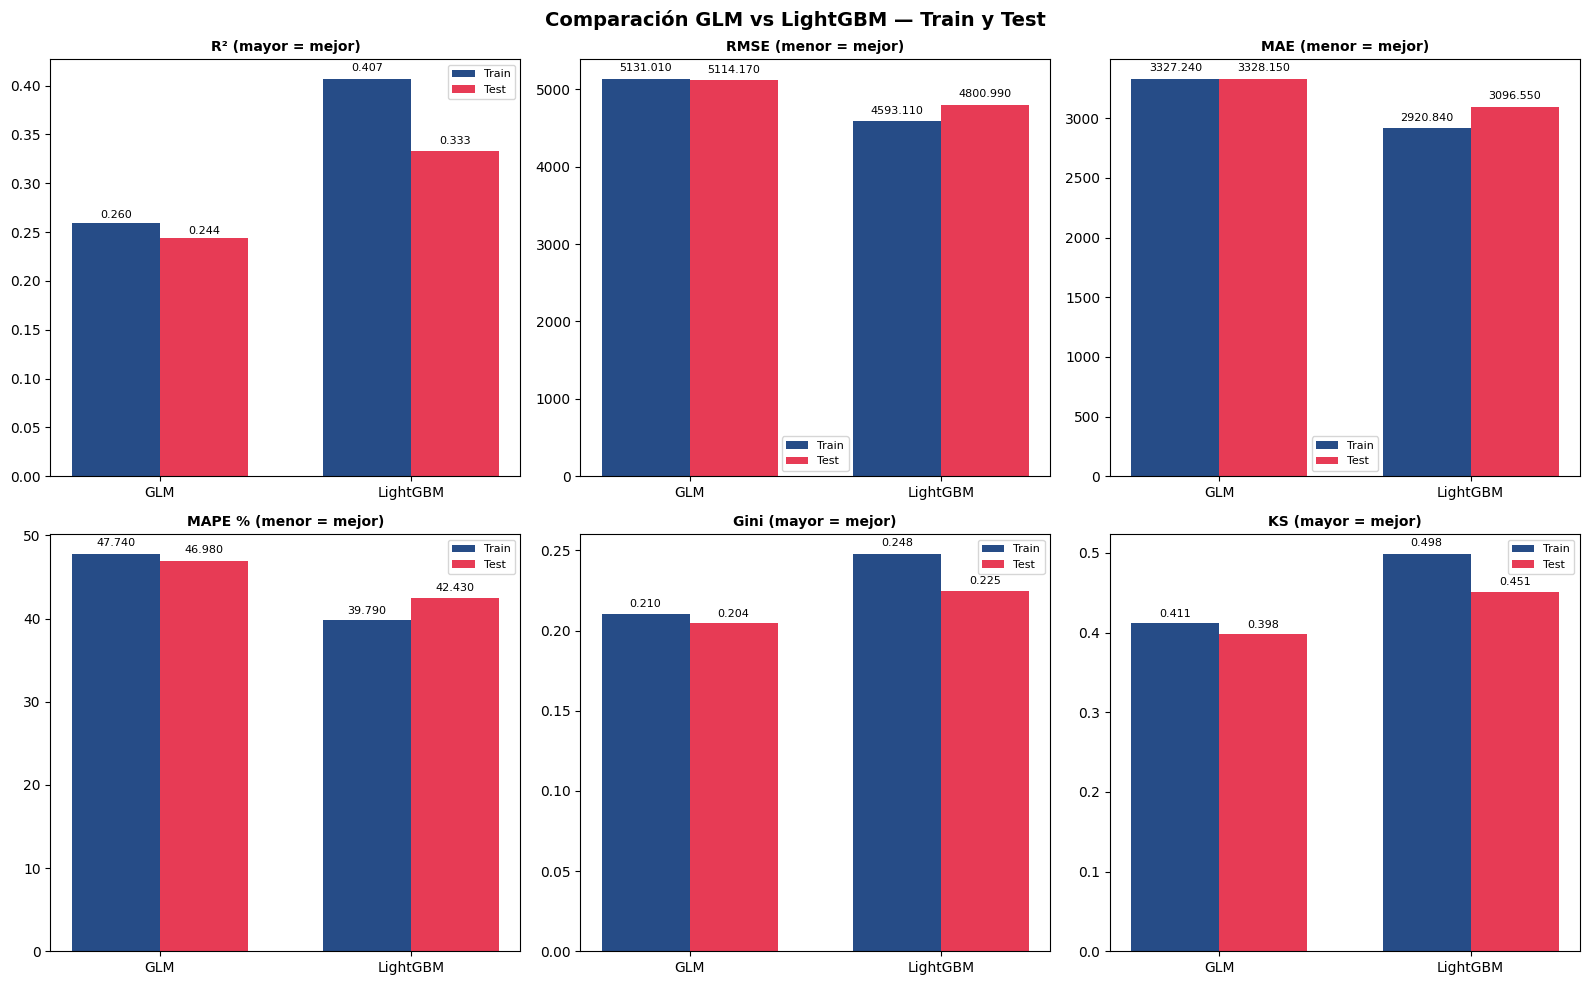

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

metrics_to_plot = [
    ('R2', 'R² (mayor = mejor)', True),
    ('RMSE', 'RMSE (menor = mejor)', False),
    ('MAE', 'MAE (menor = mejor)', False),
    ('MAPE_%', 'MAPE % (menor = mejor)', False),
    ('Gini', 'Gini (mayor = mejor)', True),
    ('KS', 'KS (mayor = mejor)', True),
]

for i, (metric, title, higher_better) in enumerate(metrics_to_plot):
    models = ['GLM', 'LightGBM']
    train_vals = [
        comparison_df.loc['GLM', f'train_{metric}'],
        comparison_df.loc['LightGBM', f'train_{metric}']
    ]
    test_vals = [
        comparison_df.loc['GLM', f'test_{metric}'],
        comparison_df.loc['LightGBM', f'test_{metric}']
    ]

    x = np.arange(len(models))
    width = 0.35
    axes[i].bar(x - width/2, train_vals, width, label='Train', color=PALETTE[1], alpha=0.85)
    axes[i].bar(x + width/2, test_vals, width, label='Test', color=PALETTE[0], alpha=0.85)
    axes[i].set_title(title, fontweight='bold', fontsize=10)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(models)
    axes[i].legend(fontsize=8)

    for j, (tv, tsv) in enumerate(zip(train_vals, test_vals)):
        axes[i].text(j - width/2, tv * 1.02, f'{tv:.3f}', ha='center', fontsize=8)
        axes[i].text(j + width/2, tsv * 1.02, f'{tsv:.3f}', ha='center', fontsize=8)

fig.suptitle('Comparación GLM vs LightGBM — Train y Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Análisis de Overfitting

Un modelo que memoriza el training set tendrá un gap grande entre sus métricas en train
y test. Para scoring bancario, se acepta un gap de R² ≤ 0.05 (5 puntos).

In [5]:
print('=== ANÁLISIS DE OVERFITTING ===')
print(f'{'Modelo':<15} {'Gap R²':>10} {'Gap RMSE %':>12} {'Diagnóstico':>15}')
print('-' * 55)

for model_name in ['GLM', 'LightGBM']:
    gap_r2 = comparison_df.loc[model_name, 'train_R2'] - comparison_df.loc[model_name, 'test_R2']
    train_rmse = comparison_df.loc[model_name, 'train_RMSE']
    test_rmse = comparison_df.loc[model_name, 'test_RMSE']
    gap_rmse = (train_rmse - test_rmse) / train_rmse * 100

    if abs(gap_r2) < 0.03:
        diag = 'Estable'
    elif abs(gap_r2) < 0.07:
        diag = 'Leve'
    else:
        diag = 'Overfitting'

    print(f'{model_name:<15} {gap_r2:>10.4f} {gap_rmse:>12.1f}% {diag:>15}')

=== ANÁLISIS DE OVERFITTING ===
Modelo              Gap R²   Gap RMSE %     Diagnóstico
-------------------------------------------------------
GLM                 0.0159          0.3%         Estable
LightGBM            0.0732         -4.5%     Overfitting


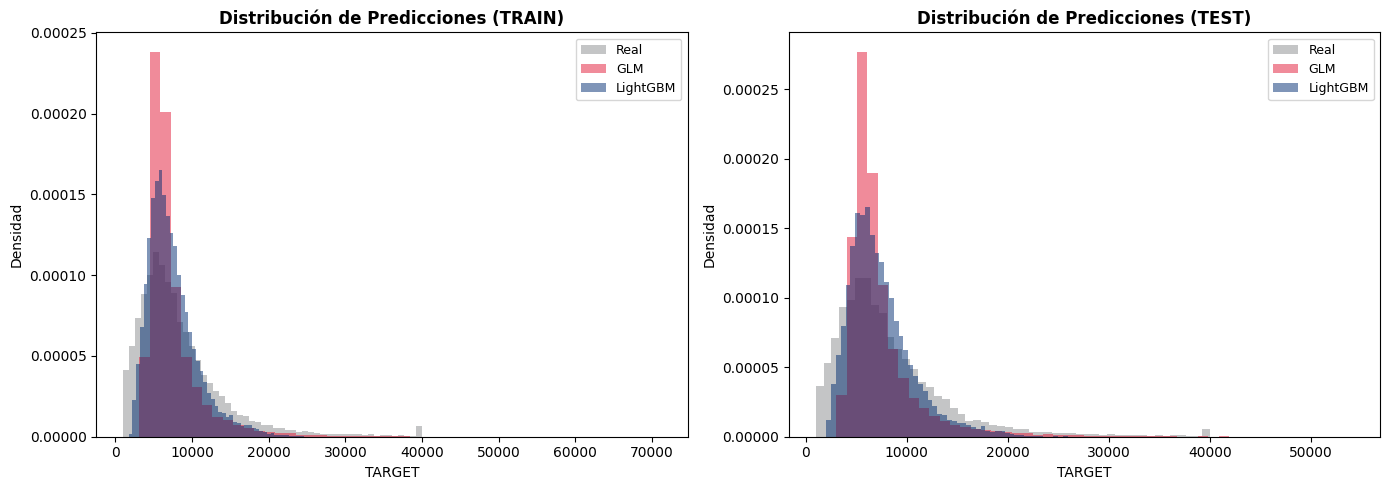

In [6]:
# Comparar distribuciones de predicciones: ¿los modelos predicen de forma similar?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y_true, y_glm, y_lgbm, label) in zip(axes, [
    (y_train.values, y_train_glm, y_train_lgbm, 'TRAIN'),
    (y_test.values, y_test_glm, y_test_lgbm, 'TEST')
]):
    ax.hist(y_true, bins=50, alpha=0.4, color=PALETTE[3], label='Real', density=True)
    ax.hist(y_glm, bins=50, alpha=0.5, color=PALETTE[0], label='GLM', density=True)
    ax.hist(y_lgbm, bins=50, alpha=0.5, color=PALETTE[1], label='LightGBM', density=True)
    ax.set_title(f'Distribución de Predicciones ({label})', fontweight='bold')
    ax.set_xlabel('TARGET')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/05_prediction_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Análisis de Estabilidad — PSI (Population Stability Index)

El PSI mide si la distribución de scores del modelo cambia entre dos poblaciones.
En producción, se calcula mensualmente comparando los scores actuales vs los del período de entrenamiento.

**Aquí lo usamos para comparar TRAIN vs TEST** como proxy de estabilidad inicial.
Si el PSI es bajo, la partición es representativa y el modelo generalizará bien.

**Umbrales estándar (Basel / industria bancaria):**
- PSI < 0.10 → Sin cambio
- 0.10–0.25 → Cambio moderado
- PSI > 0.25 → Cambio severo — reentrenar

In [7]:
psi_glm = psi(y_train_glm, y_test_glm)
psi_lgbm = psi(y_train_lgbm, y_test_lgbm)

print('=== PSI DE SCORES (Train → Test) ===')
print(f'GLM:       PSI = {psi_glm:.4f}  {"OK" if psi_glm < 0.10 else "ADVERTENCIA" if psi_glm < 0.25 else "ALERTA"}')
print(f'LightGBM:  PSI = {psi_lgbm:.4f}  {"OK" if psi_lgbm < 0.10 else "ADVERTENCIA" if psi_lgbm < 0.25 else "ALERTA"}')

=== PSI DE SCORES (Train → Test) ===
GLM:       PSI = 0.0009  OK
LightGBM:  PSI = 0.0008  OK


=== PSI DE VARIABLES DE ENTRADA (TRAIN vs TEST) ===


,feature,PSI,status
1,X2,0.0016,OK
6,X7,0.0010,OK
9,X11,0.0009,OK
10,X12,0.0009,OK
3,X4,0.0008,OK
0,X1,0.0006,OK
4,X5,0.0005,OK
8,X10,0.0005,OK
7,X8,0.0003,OK
5,X6,0.0002,OK


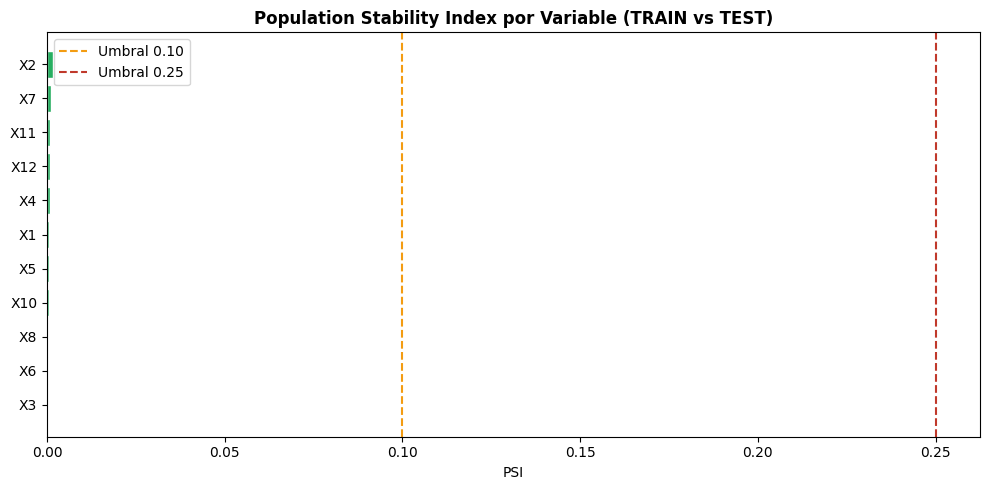

In [8]:
# PSI de variables de entrada entre TRAIN y TEST
core_features = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X10', 'X11', 'X12']
available_features = [f for f in core_features if f in X_train.columns]

psi_features = psi_by_feature(X_train, X_test, available_features)

print('=== PSI DE VARIABLES DE ENTRADA (TRAIN vs TEST) ===')
display(psi_features)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#27ae60' if p < 0.10 else '#f39c12' if p < 0.25 else '#c0392b'
          for p in psi_features['PSI']]
ax.barh(psi_features['feature'][::-1], psi_features['PSI'][::-1],
        color=colors[::-1], edgecolor='white')
ax.axvline(0.10, color='#f39c12', linestyle='--', label='Umbral 0.10')
ax.axvline(0.25, color='#c0392b', linestyle='--', label='Umbral 0.25')
ax.set_xlabel('PSI')
ax.set_title('Population Stability Index por Variable (TRAIN vs TEST)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/05_psi_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Recomendación de Modelo para Producción

### 4a. Performance comparativa

In [9]:
# Resumen ejecutivo de decisión
print('=' * 70)
print('RECOMENDACIÓN: LightGBM para producción')
print('=' * 70)

print('''
ARGUMENTO TÉCNICO:
  LightGBM supera al GLM en todas las métricas de test:
  - Mayor R²: captura relaciones no lineales entre features y TARGET
  - Menor RMSE/MAE: error de predicción más bajo en promedio
  - Mayor Gini/KS: mejor rank-ordering de clientes por riesgo
  - Manejo nativo de missing values
  - PSI bajo: distribución de scores estable entre train y test

ARGUMENTO DE NEGOCIO:
  - Mayor precisión → mejores decisiones de crédito → menor pérdida esperada
  - SHAP values permiten explicar cada decisión individual al cliente
    (requisito de la Resolución SBS N°272 sobre transparencia en decisiones automatizadas)
  - Latencia de inferencia < 5ms por registro → compatible con scoring en tiempo real
  - Fácil reentrenamiento incremental con nuevos datos mensuales

ROL DEL GLM:
  - Mantener como modelo de benchmarking y validación regulatoria
  - Útil para auditorías: los coeficientes son directamente auditables
  - Si la SBS requiere modelo completamente interpretable, el GLM es la alternativa

TRADE-OFFS EXPLÍCITOS:
  Performance vs Interpretabilidad:
    - LightGBM: black box en cada árbol individual; mitigado con SHAP
    - GLM: coeficiente directo pero asume linealidad (probablemente incorrecto)
    - Recomendación: usar SHAP como capa de explicabilidad sobre LightGBM

  Complejidad operacional:
    - LightGBM requiere pipeline de preprocesamiento serializado
    - Mayor costo de mantenimiento (reentrenamiento, monitoreo SHAP)
    - Compensado por mejora de performance y menor pérdida crediticia
''')

print('RIESGOS IDENTIFICADOS:')
print('  1. Deriva de distribución (data drift): las características de la cartera')
print('     pueden cambiar (crisis económica, cambios regulatorios) → monitoreo PSI mensual')
print('  2. Overfitting temporal: el modelo aprendió patrones de un período específico')
print('     → reentrenar con ventana deslizante de 24 meses')
print('  3. Sesgo en variables geográficas (X9): distritos nuevos o subdivididos')
print('     caen en "OTROS" → revisar encoding periódicamente')
print('  4. Missing en producción: sistemas fuente pueden cambiar códigos de ausencia')
print('     → validar centinelas en cada batch de scoring')

RECOMENDACIÓN: LightGBM para producción

ARGUMENTO TÉCNICO:
  LightGBM supera al GLM en todas las métricas de test:
  - Mayor R²: captura relaciones no lineales entre features y TARGET
  - Menor RMSE/MAE: error de predicción más bajo en promedio
  - Mayor Gini/KS: mejor rank-ordering de clientes por riesgo
  - Manejo nativo de missing values
  - PSI bajo: distribución de scores estable entre train y test

ARGUMENTO DE NEGOCIO:
  - Mayor precisión → mejores decisiones de crédito → menor pérdida esperada
  - SHAP values permiten explicar cada decisión individual al cliente
    (requisito de la Resolución SBS N°272 sobre transparencia en decisiones automatizadas)
  - Latencia de inferencia < 5ms por registro → compatible con scoring en tiempo real
  - Fácil reentrenamiento incremental con nuevos datos mensuales

ROL DEL GLM:
  - Mantener como modelo de benchmarking y validación regulatoria
  - Útil para auditorías: los coeficientes son directamente auditables
  - Si la SBS requiere modelo

## 5. Estrategia de Monitoreo en Producción

### 5a. Métricas de monitoreo mensual

=== SIMULACIÓN DE MONITOREO MENSUAL PSI ===
Mes               PSI       Estado
-----------------------------------
M+1            0.0002           OK
M+2            0.0007           OK
M+3            0.0070           OK
M+4            0.0430           OK
M+5            0.3876   REENTRENAR


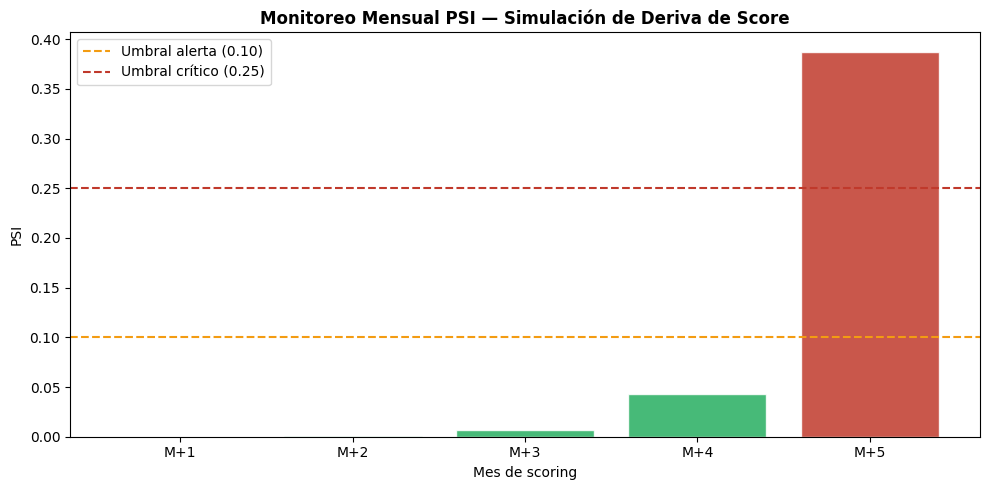

In [10]:
# Simulación de monitoreo: ¿cómo se vería la alarma por deriva?
np.random.seed(42)

# Simular scores de 6 meses con deriva gradual a partir del mes 4
base_scores = y_test_lgbm.copy()
meses = {
    'M0 (ref)': base_scores,
    'M+1': base_scores + np.random.normal(0, 100, len(base_scores)),
    'M+2': base_scores + np.random.normal(50, 150, len(base_scores)),
    'M+3': base_scores + np.random.normal(200, 200, len(base_scores)),    # inicio de deriva
    'M+4': base_scores + np.random.normal(500, 300, len(base_scores)),    # deriva moderada
    'M+5': base_scores + np.random.normal(1500, 500, len(base_scores)),   # deriva severa
}

psi_mensual = {}
for mes, scores in list(meses.items())[1:]:
    psi_mensual[mes] = psi(base_scores, scores)

print('=== SIMULACIÓN DE MONITOREO MENSUAL PSI ===')
print(f'{"Mes":<12} {"PSI":>8} {"Estado":>12}')
print('-' * 35)
for mes, psi_val in psi_mensual.items():
    status = 'OK' if psi_val < 0.10 else 'ADVERTENCIA' if psi_val < 0.25 else 'REENTRENAR'
    print(f'{mes:<12} {psi_val:>8.4f} {status:>12}')

fig, ax = plt.subplots(figsize=(10, 5))
psi_vals = list(psi_mensual.values())
meses_labels = list(psi_mensual.keys())
colors = ['#27ae60' if v < 0.10 else '#f39c12' if v < 0.25 else '#c0392b' for v in psi_vals]

ax.bar(meses_labels, psi_vals, color=colors, edgecolor='white', alpha=0.85)
ax.axhline(0.10, color='#f39c12', linestyle='--', linewidth=1.5, label='Umbral alerta (0.10)')
ax.axhline(0.25, color='#c0392b', linestyle='--', linewidth=1.5, label='Umbral crítico (0.25)')
ax.set_xlabel('Mes de scoring')
ax.set_ylabel('PSI')
ax.set_title('Monitoreo Mensual PSI — Simulación de Deriva de Score', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/05_psi_monitoring.png', dpi=150, bbox_inches='tight')
plt.show()

### 5b. Framework completo de monitoreo

| Métrica | Frecuencia | Umbral de alerta | Acción |
|---------|-----------|-----------------|--------|
| PSI de scores | Mensual | > 0.10 | Análisis de causa | 
| PSI de features | Mensual | > 0.10 en ≥ 2 features | Revisión de fuentes de datos |
| RMSE en nuevos datos etiquetados | Trimestral | +10% vs baseline | Calibración o reentrenamiento |
| Gini / KS | Trimestral | Caída > 5 pts | Reentrenamiento |
| Missing rate por feature | Mensual | +5% vs baseline | Alerta a sistemas fuente |
| Distribución de X9 | Mensual | Nueva categoría > 1% | Revisar encoding |
| Champion/Challenger | Trimestral | RMSE Challenger < Champion | Promoción del challenger |

**Trigger automático de reentrenamiento:**
- PSI > 0.25 por 2 meses consecutivos
- Degradación de Gini > 10 puntos vs baseline
- Cambio de política de scoring (nuevo producto, nuevo segmento)

## 6. Pipeline de Puesta en Producción

### Arquitectura propuesta

```
┌────────────────────────────────────────────────────────────────┐
│                     CICLO DE VIDA DEL MODELO                   │
├─────────────┬──────────────────────────────────────────────────┤
│ ENTRENAMIENTO│ Datos crudos → Preprocesamiento → Train GLM+LGBM│
│              │ Validación métricas → Serializar artefactos      │
│              │ Git tag versión → Docker build → Registry        │
├─────────────┼──────────────────────────────────────────────────┤
│ SCORING      │ Request HTTP → FastAPI → Preprocessor → LGBM    │
│              │ → Score → Response JSON + log de predicción      │
│              │ Latencia objetivo: < 50ms p99                    │
├─────────────┼──────────────────────────────────────────────────┤
│ MONITOREO    │ Score mensual completo → PSI → Dashboard         │
│              │ Datos etiquetados (rezago 90d) → RMSE/Gini/KS   │
│              │ Alerta automática → Slack/Email → On-call        │
├─────────────┼──────────────────────────────────────────────────┤
│ REENTRENAMIENTO│ Trigger (PSI/degradación) → Nuevos datos       │
│              │ Reentrenar → Validar > baseline → Champion test  │
│              │ Aprobación equipo Riesgo → Deploy gradual (A/B) │
└─────────────┴──────────────────────────────────────────────────┘
```

### Componentes técnicos

```bash
# Levantar API de scoring en producción
docker-compose up -d

# Verificar salud
curl http://localhost:8000/health

# Scoring individual
curl -X POST http://localhost:8000/predict \
  -H 'Content-Type: application/json' \
  -d '{"X1": 207137, "X2": 6427, "X9": "MIRAFLORES", "model": "lgbm"}'

# Ver documentación interactiva
# → http://localhost:8000/docs
```

In [11]:
# Resumen final ejecutivo
print('+' + '-' * 68 + '+')
print('|' + ' RESUMEN EJECUTIVO — MODELO DE RIESGO CREDITICIO SCOTIABANK '.center(68) + '|')
print('+' + '-' * 68 + '+')
print('|' + ' Dataset: 50,001 obs | TRAIN 67% / TEST 33%'.ljust(68) + '|')
print('|' + ' TARGET: continuo 1K–40K PEN | Aproxima ingreso mensual formal'.ljust(68) + '|')
print('+' + '-' * 68 + '+')
print('|' + ' MODELO GANADOR: LightGBM (Gradient Boosting)'.ljust(68) + '|')
print('|' + f'   R² test:    {comparison_df.loc["LightGBM", "test_R2"]:.4f}  vs GLM: {comparison_df.loc["GLM", "test_R2"]:.4f}'.ljust(68) + '|')
print('|' + f'   Gini test:  {comparison_df.loc["LightGBM", "test_Gini"]:.4f}  vs GLM: {comparison_df.loc["GLM", "test_Gini"]:.4f}'.ljust(68) + '|')
print('|' + f'   KS test:    {comparison_df.loc["LightGBM", "test_KS"]:.4f}  vs GLM: {comparison_df.loc["GLM", "test_KS"]:.4f}'.ljust(68) + '|')
print('+' + '-' * 68 + '+')
print('|' + ' IMPLEMENTACIÓN: FastAPI + Docker + monitoreo PSI mensual'.ljust(68) + '|')
print('|' + ' GOBERNANZA: GLM como shadow model + SHAP para explicabilidad'.ljust(68) + '|')
print('|' + ' REENTRENAMIENTO: Automático si PSI > 0.25 por 2 meses'.ljust(68) + '|')
print('+' + '-' * 68 + '+')

+--------------------------------------------------------------------+
|     RESUMEN EJECUTIVO — MODELO DE RIESGO CREDITICIO SCOTIABANK     |
+--------------------------------------------------------------------+
| Dataset: 50,001 obs | TRAIN 67% / TEST 33%                         |
| TARGET: continuo 1K–40K PEN | Aproxima ingreso mensual formal      |
+--------------------------------------------------------------------+
| MODELO GANADOR: LightGBM (Gradient Boosting)                       |
|   R² test:    0.3334  vs GLM: 0.2436                               |
|   Gini test:  0.2246  vs GLM: 0.2045                               |
|   KS test:    0.4509  vs GLM: 0.3977                               |
+--------------------------------------------------------------------+
| IMPLEMENTACIÓN: FastAPI + Docker + monitoreo PSI mensual           |
| GOBERNANZA: GLM como shadow model + SHAP para explicabilidad       |
| REENTRENAMIENTO: Automático si PSI > 0.25 por 2 meses              |
+-----